<a href="https://colab.research.google.com/github/chlaitha/real-world-industry-projects/blob/main/Flight_Delay_Prediction_%26_Operational_Risk_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flight Delay Prediction & Operational Risk Analytics
This notebook presents an end-to-end analytical pipeline to investigate, quantify, and predict flight delays using the 2015 Flight Delays and Cancellations dataset.

# 1. Project Overview & Environment Setup

### Business Problem & Objectives
Flight delays disrupt passenger schedules, trigger crew overtime costs, and create compounding network bottlenecks across hub airports. Predicting flight delays before departure allows airlines and airport authorities to optimize gate assignments, manage staffing buffers, and offer proactive rebooking options.

### Objectives
1. **Data Preprocessing & Cleaning**: Handle missing delay attributes and extract temporal features (e.g., departure hour).
2. **Exploratory Data Analysis**: Evaluate on-time performance across carriers, day of week, and departure time windows.
3. **Delay Attribution**: Breakdown root causes of major delays (Weather, Airline Control, NAS, Late Aircraft).
4. **Predictive Modeling**: Train a LightGBM classification model to predict whether a flight will experience an arrival delay exceeding 15 minutes.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Mount Google drive & load data
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd

df_flights  = pd.read_csv('/content/gdrive/My Drive/Notebooks/aviation/flights.csv')
df_airlines = pd.read_csv('/content/gdrive/My Drive/Notebooks/aviation/airlines.csv')
df_airports = pd.read_csv('/content/gdrive/My Drive/Notebooks/aviation/airports.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [4]:
df_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [5]:
# 1. Merge Airline Names for Readable Visualizations
flights = df_flights.merge(
    df_airlines,
    left_on='AIRLINE',
    right_on='IATA_CODE',
    how='left',
    suffixes=('', '_carrier')
)
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE,AIRLINE_carrier
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.


In [6]:
# 2. Filter Out Canceled Flights for Arrival Delay Analysis
flights_active = flights[flights['CANCELLED'] == 0].copy()

# 3. Target Variable Definition (1 = Arrival Delay > 15 Mins)
flights_active['IS_DELAYED'] = (flights_active['ARRIVAL_DELAY'] > 15).astype(int)

# 4. Feature Engineering: Extract Departure Hour (from hhmm integer format)
flights_active['SCHED_DEP_HOUR'] = flights_active['SCHEDULED_DEPARTURE'] // 100

print(f"--Total Active Flights Evaluated--: {len(flights_active):,}")
flights_active[['AIRLINE_carrier', 'SCHEDULED_DEPARTURE', 'SCHED_DEP_HOUR', 'ARRIVAL_DELAY', 'IS_DELAYED']].head()

--Total Active Flights Evaluated--: 5,729,195


,AIRLINE_carrier,SCHEDULED_DEPARTURE,SCHED_DEP_HOUR,ARRIVAL_DELAY,IS_DELAYED
0,Alaska Airlines Inc.,5,0,-22.0,0
1,American Airlines Inc.,10,0,-9.0,0
2,US Airways Inc.,20,0,5.0,0
3,American Airlines Inc.,20,0,-9.0,0
4,Alaska Airlines Inc.,25,0,-21.0,0


# 2. Exploratory Data Analysis & Delay Root-Cause Attribution

We evaluate key delay dynamics across carriers, time of day, and specific delay causes:
* **Carrier Performance**: On-time rates across major US airlines.
* **Temporal Patterns**: How delay probabilities escalate from morning to evening peak hours.
* **Delay Breakdown**: Relative contribution of Air System, Airline Control, Late Aircraft, and Weather delays.

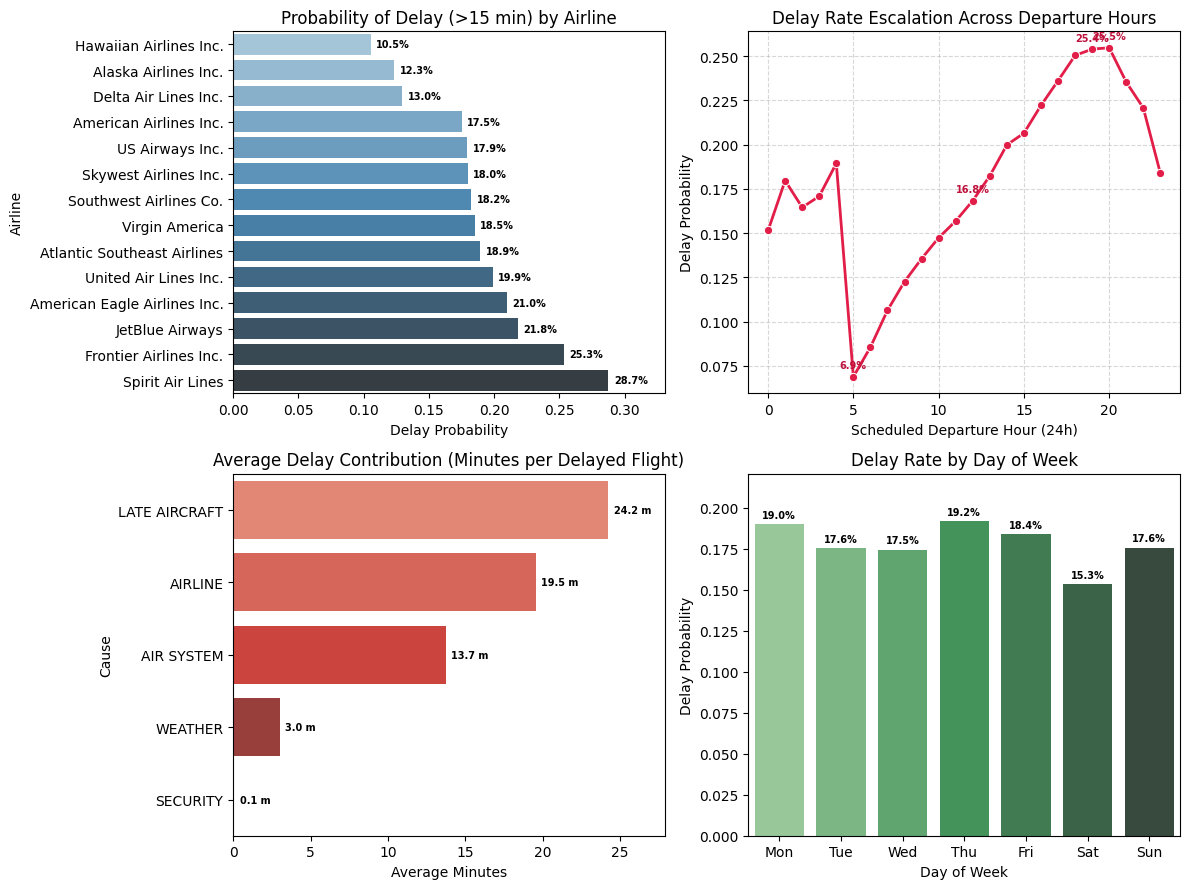

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plt.subplots_adjust(hspace=0.35, wspace=0.30)

# Plot 1: On-Time Performance by Airline
carrier_delay = flights_active.groupby('AIRLINE_carrier')['IS_DELAYED'].mean().sort_values().reset_index()
barplot1 = sns.barplot(
    data=carrier_delay, y='AIRLINE_carrier', x='IS_DELAYED',
    ax=axes[0, 0], palette='Blues_d'
)
axes[0, 0].set_title('Probability of Delay (>15 min) by Airline')
axes[0, 0].set_xlabel('Delay Probability')
axes[0, 0].set_ylabel('Airline')

# Annotate numeric values on bars for Plot 1
for p in barplot1.patches:
    width = p.get_width()
    axes[0, 0].annotate(
        f'{width:.1%}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(4, 0), textcoords='offset points',
        fontsize=7, fontweight='bold'
    )
axes[0, 0].set_xlim(0, carrier_delay['IS_DELAYED'].max() * 1.15)


# Plot 2: Delay Rate by Scheduled Departure Hour
hourly_delay = flights_active.groupby('SCHED_DEP_HOUR')['IS_DELAYED'].mean().reset_index()
sns.lineplot(
    data=hourly_delay, x='SCHED_DEP_HOUR', y='IS_DELAYED',
    ax=axes[0, 1], marker='o', color='#e11d48', linewidth=2
)
axes[0, 1].set_title('Delay Rate Escalation Across Departure Hours')
axes[0, 1].set_xlabel('Scheduled Departure Hour (24h)')
axes[0, 1].set_ylabel('Delay Probability')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Annotate key min/max peak data points for Plot 2
for _, row in hourly_delay.iterrows():
    hour = int(row['SCHED_DEP_HOUR'])
    val = row['IS_DELAYED']
    # Label key inflection points (morning low, peak evening) to avoid visual clutter
    if hour in [5, 12, 19, 20]:
        axes[0, 1].annotate(
            f'{val:.1%}',
            (hour, val),
            xytext=(0, 6), textcoords='offset points',
            ha='center', fontsize=7, fontweight='bold', color='#be123c'
        )


# Plot 3: Delay Root Cause Composition (For Flights Delayed > 15 Mins)
delay_causes = ['AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIR_SYSTEM_DELAY', 'WEATHER_DELAY', 'SECURITY_DELAY']
delay_means = flights_active[flights_active['IS_DELAYED'] == 1][delay_causes].mean().reset_index()
delay_means.columns = ['Cause', 'Avg_Minutes']
delay_means['Cause'] = delay_means['Cause'].str.replace('_DELAY', '').str.replace('_', ' ')
delay_means = delay_means.sort_values('Avg_Minutes', ascending=False)

barplot3 = sns.barplot(
    data=delay_means,
    x='Avg_Minutes', y='Cause', ax=axes[1, 0], palette='Reds_d'
)
axes[1, 0].set_title('Average Delay Contribution (Minutes per Delayed Flight)')
axes[1, 0].set_xlabel('Average Minutes')

# Annotate numeric values on bars for Plot 3
for p in barplot3.patches:
    width = p.get_width()
    axes[1, 0].annotate(
        f'{width:.1f} m',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(4, 0), textcoords='offset points',
        fontsize=7, fontweight='bold'
    )
axes[1, 0].set_xlim(0, delay_means['Avg_Minutes'].max() * 1.15)


# Plot 4: Arrival Delay Distribution by Day of Week
day_delay = flights_active.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean().reset_index()
day_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_delay['Day_Name'] = day_delay['DAY_OF_WEEK'].map(day_labels)

barplot4 = sns.barplot(
    data=day_delay, x='Day_Name', y='IS_DELAYED',
    ax=axes[1, 1], palette='Greens_d'
)
axes[1, 1].set_title('Delay Rate by Day of Week')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Delay Probability')

# Annotate numeric values above bars for Plot 4
for p in barplot4.patches:
    height = p.get_height()
    axes[1, 1].annotate(
        f'{height:.1%}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 3), textcoords='offset points',
        fontsize=7, fontweight='bold'
    )
axes[1, 1].set_ylim(0, day_delay['IS_DELAYED'].max() * 1.15)

plt.tight_layout()
plt.show()

# 3. Machine Learning Pipeline (LightGBM)

We train a **LightGBM** binary classification model to predict `IS_DELAYED` using point-in-time features known prior to departure.

### Feature Selection
* **Categorical**: `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`
* **Numerical/Temporal**: `MONTH`, `DAY`, `DAY_OF_WEEK`, `SCHED_DEP_HOUR`, `DISTANCE`

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 818798, number of negative: 3764558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1143
[LightGBM] [Info] Number of data points in the train set: 4583356, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.178646 -> initscore=-1.525548
[LightGBM] [Info] Start training from score -1.525548
ROC-AUC Score: 0.7114

Classification Report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90    941139
           1       0.69      0.02      0.05    2047

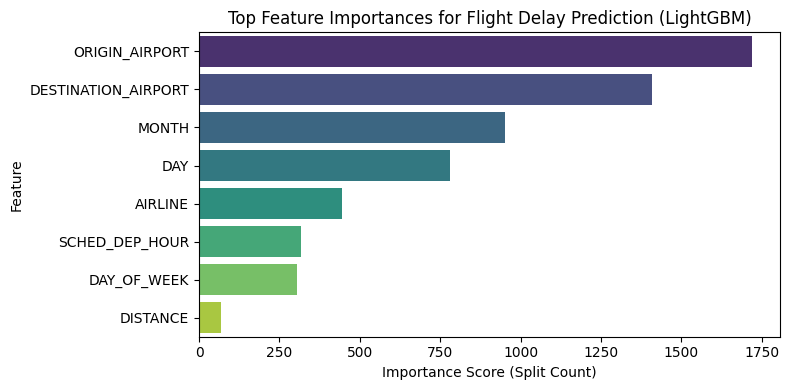

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from lightgbm import LGBMClassifier

# 1. Feature & Target Matrix
feature_cols = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHED_DEP_HOUR', 'DISTANCE'
]

X = flights_active[feature_cols].copy()
y = flights_active['IS_DELAYED']

# Convert text/categorical columns to category dtype for LightGBM
cat_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
for col in cat_cols:
    X[col] = X[col].astype('category')

# 2. Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Model Training
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Top Feature Importances Plot
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance, x='importance', y='feature', palette='viridis')
plt.title('Top Feature Importances for Flight Delay Prediction (LightGBM)')
plt.xlabel('Importance Score (Split Count)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#4: Key Findings & Action Plan
### Key Findings

* **Carrier Performance Variance:** Across 5.7M evaluated flights, overall delay probability averages 17.9%. Hawaiian (10.6%) and Alaska (12.4%) demonstrate top punctuality, whereas budget carriers like Spirit (28.7%) and Frontier (25.3%) experience the highest delay risks.
* **Hourly Escalation:** Delay rates drop to a daily minimum at 05:00 (6.9%) before steadily compounding throughout the operating day to peak between 18:00 and 20:00 (>25.0%).
* **Delay Attribution:** Operational delays are overwhelmingly driven by `LATE AIRCRAFT` (24.2 min/delayed flight) and `AIRLINE` control (19.6 min/delayed flight), confirming that rotational bottlenecks dominate over direct weather events (3.0 min/delayed flight).
* **Day-of-Week Patterns:** Delay probabilities peak on Mondays (19.0%) and Thursdays (19.2%), while Saturdays represent the smoothest operational window (15.3%).
* **Predictive Model Performance:** The LightGBM classifier achieves an ROC-AUC of 0.7114 and 82% overall accuracy. However, using the default 0.5 decision threshold on imbalanced data yields low recall (0.02) for delayed flights, highlighting the need for threshold adjustment.

---

### Action Plan

1. **Carrier-Specific Ground Support**  
   Target operational process improvements and ground-handling efficiency for high-delay carrier segments (Spirit, Frontier, JetBlue) to reduce baseline delay risks.

2. **Rotational Buffer Allocation**  
   Inject dynamic turnaround time buffers into mid-to-late afternoon aircraft rotations to prevent early delays from compounding into peak evening hours (18:00–20:00).

3. **Turnaround & Gate Management**  
   Focus gate management strategies on mitigating late-aircraft arrivals and carrier-controlled turnaround delays rather than prioritizing rare weather disruptions.

4. **Off-Peak Travel & Scheduling**  
   Shift flexible flight scheduling and offer passenger incentives toward low-risk departure windows (05:00–07:00) and lighter travel days (Saturdays) to reduce overall network congestion.

5. **Decision Threshold Tuning**  
   Lower the model's classification probability threshold (or apply class weighting) to optimize recall, allowing operations to proactively flag at-risk flights before departure.